# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
|              |       |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [21]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [22]:
#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.



data = pd.read_csv('WineQT.csv')
data.head()
data.info()
data.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


dari tabel statistik yang ada saya mendapatkan insight bahwa kebanyakan dari fitur tersebut bukan distribusi normal 

In [23]:
print("Duplikat tanpa kolom Id:", data.drop(columns=['Id']).duplicated().sum())

duplikat = data[data.drop(columns=['Id']).duplicated(keep=False)].sort_values(by='quality')
print("Jumlah baris yang terlibat duplikat:", len(duplikat))
display(duplikat.head(10))


Duplikat tanpa kolom Id: 125
Jumlah baris yang terlibat duplikat: 239


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4
45,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.9962,3.41,0.39,10.9,5,64
46,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.9962,3.41,0.39,10.9,5,65
60,7.7,0.490,0.26,1.90,0.062,9.0,31.0,0.9966,3.39,0.64,9.6,5,87
65,7.7,0.490,0.26,1.90,0.062,9.0,31.0,0.9966,3.39,0.64,9.6,5,93
72,8.1,0.575,0.22,2.10,0.077,12.0,65.0,0.9967,3.29,0.51,9.2,5,103
74,8.1,0.575,0.22,2.10,0.077,12.0,65.0,0.9967,3.29,0.51,9.2,5,105
93,8.4,0.745,0.11,1.90,0.090,16.0,63.0,0.9965,3.19,0.82,9.6,5,135
95,8.4,0.745,0.11,1.90,0.090,16.0,63.0,0.9965,3.19,0.82,9.6,5,140


dari cell code tersebut saya mendapatkan insight bahwa ada 125 baris duplicate

In [24]:
data_clean = data.drop(columns=['Id']).drop_duplicates(keep='first')


data_clean = data_clean.reset_index(drop=True)

print("Sesudah:", data_clean.shape)
print("Baris terhapus:", data.shape[0] - data_clean.shape[0])

Sesudah: (1018, 12)
Baris terhapus: 125


untuk baris yang duplicate saya melakukan drop untuk mencegah noise

C:\Users\pranaja\AppData\Local\Temp\ipykernel_12700\2934988157.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=qc.index, y=qc.values, palette='viridis')


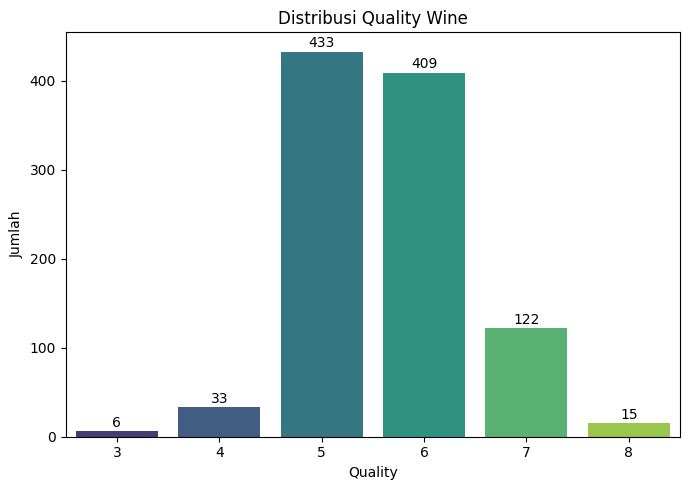

quality
3      6
4     33
5    433
6    409
7    122
8     15
Name: count, dtype: int64
quality
3     0.59
4     3.24
5    42.53
6    40.18
7    11.98
8     1.47
Name: count, dtype: float64


In [25]:
qc = data_clean['quality'].value_counts().sort_index()

plt.figure(figsize=(7,5))
sns.barplot(x=qc.index, y=qc.values, palette='viridis')
plt.title('Distribusi Quality Wine')
plt.xlabel('Quality')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)

# Tampilkan angka di atas bar
for i, v in enumerate(qc.values):
    plt.text(i, v + 5, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(qc)
print((qc / len(data_clean) * 100).round(2))

dari visualisasi tersebut saya mendapatkan insight bahwa untuk fitur kategori quality ada imbalance

In [26]:
from sklearn.model_selection import train_test_split

# Buat label binary SETELAH cleaning, SEBELUM split
data_clean['label'] = (data_clean['quality'] >= 6).astype(int)  # 0=bad, 1=good

print(data_clean['label'].value_counts())
print(data_clean['label'].value_counts(normalize=True).round(3))

X = data_clean.drop(columns=['quality', 'label'])
y = data_clean['label']

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # jaga distribusi quality tetap sama
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("\nDistribusi train (%):")
print((y_train.value_counts(normalize=True)*100).round(2))
print("\nDistribusi test (%):")
print((y_test.value_counts(normalize=True)*100).round(2))

label
1    546
0    472
Name: count, dtype: int64
label
1    0.536
0    0.464
Name: proportion, dtype: float64
X_train: (814, 11)
X_test : (204, 11)

Distribusi train (%):
label
1    53.69
0    46.31
Name: proportion, dtype: float64

Distribusi test (%):
label
1    53.43
0    46.57
Name: proportion, dtype: float64


saya melakukan split untuk membuat dataset sebagai test 

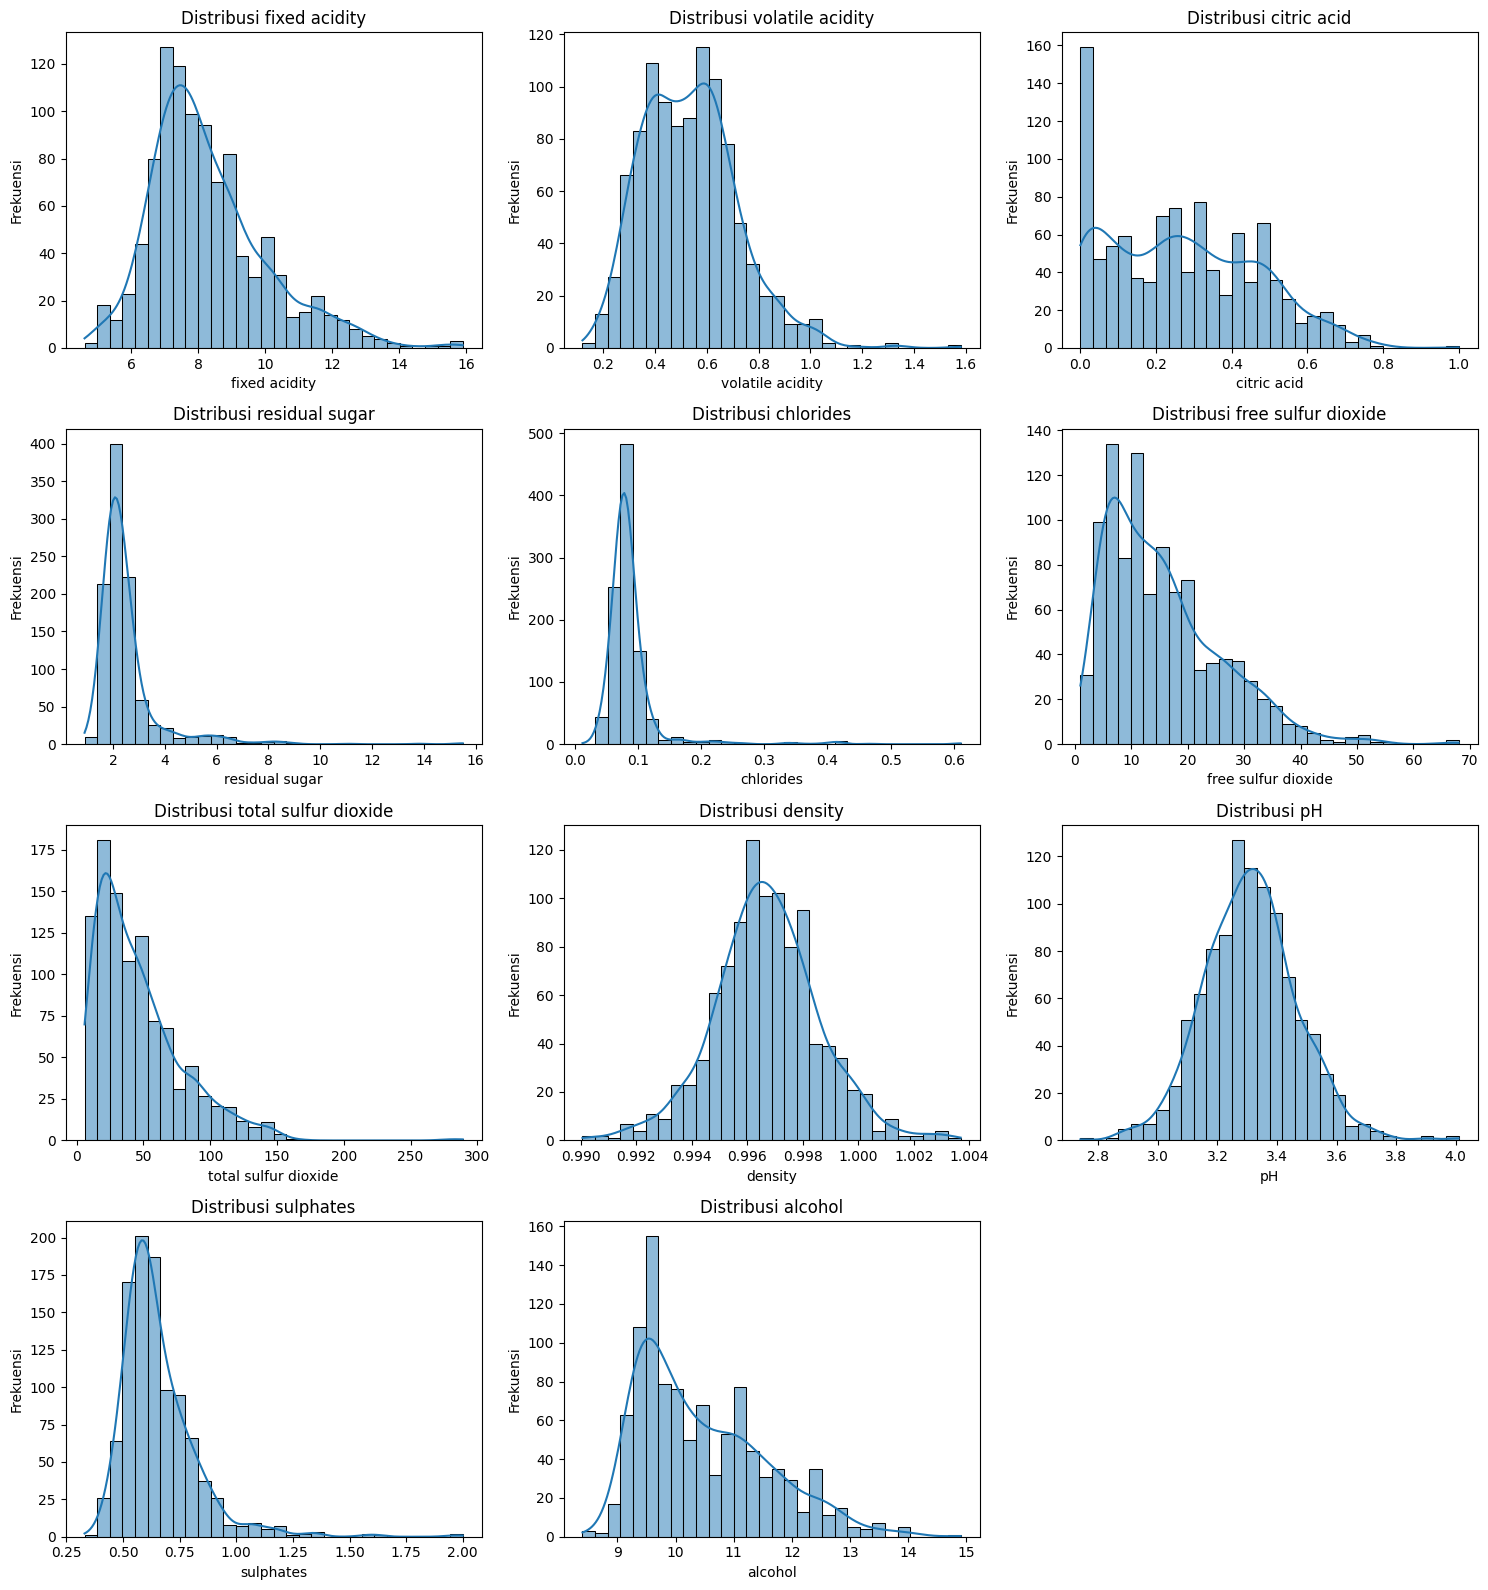

In [27]:
features = X.columns.tolist()  # 11 fitur tanpa 'quality'

n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(data=data_clean, x=col, kde=True, bins=30)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

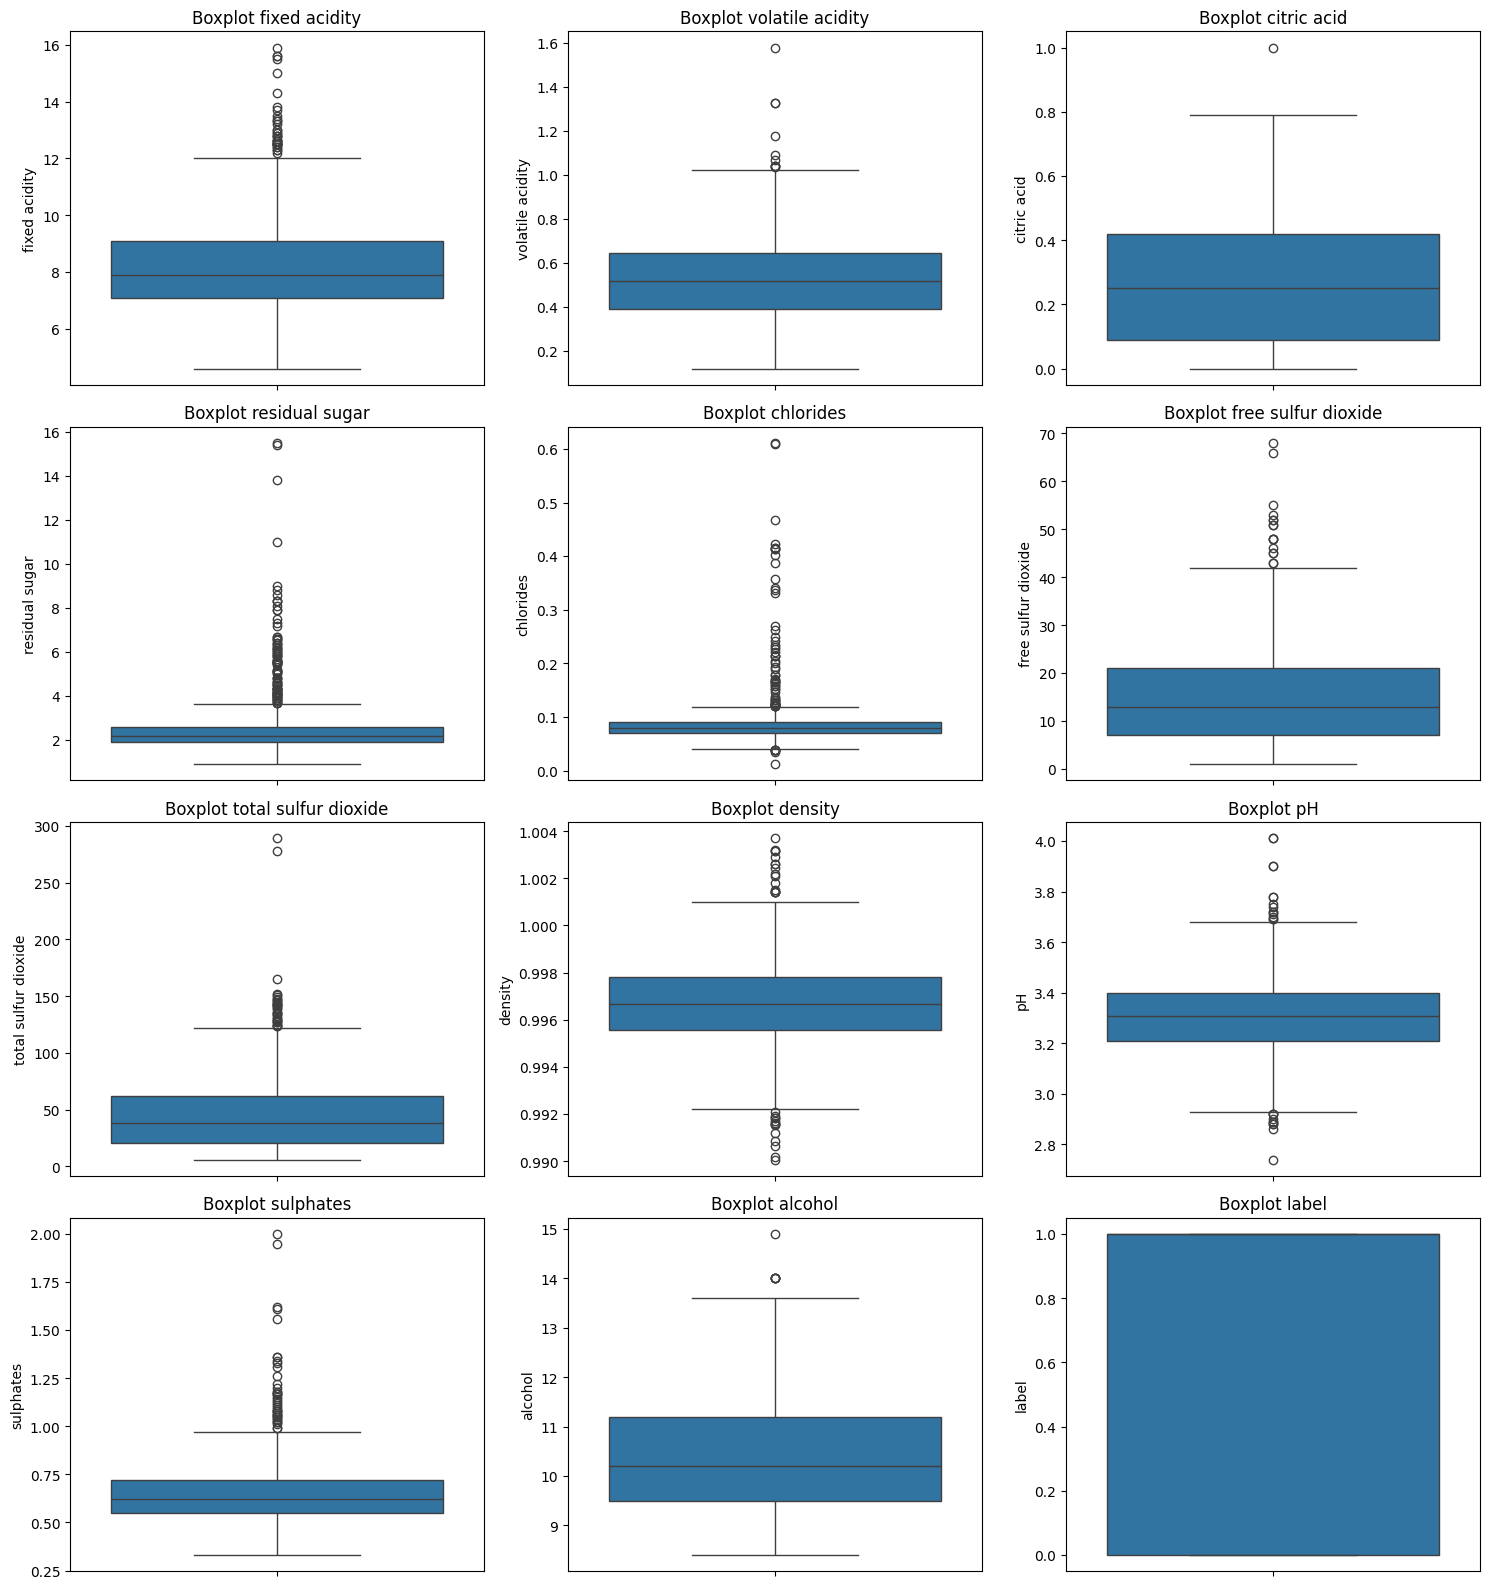

In [28]:
features = data_clean.drop(columns=['quality']).columns.tolist()

n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(data=data_clean, y=col)
    plt.title(f'Boxplot {col}')

plt.tight_layout()
plt.show()

dari distribusi box plot dapat kita lihat ada outliers pada setiap fitur

label                  -0.146
density                 0.092
pH                      0.258
citric acid             0.369
volatile acidity        0.720
alcohol                 0.849
fixed acidity           1.037
free sulfur dioxide     1.172
total sulfur dioxide    1.680
sulphates               2.425
residual sugar          4.350
chlorides               5.933
dtype: float64

Mendekati normal (pakai Z-score): ['label', 'density', 'pH', 'citric acid', 'volatile acidity', 'alcohol']
Skew (pakai log1p): ['fixed acidity', 'free sulfur dioxide', 'total sulfur dioxide', 'sulphates', 'residual sugar', 'chlorides']
Shape sebelum: (1018, 13)
Baris dibuang sebagai outlier: 26
Shape sesudah: (992, 13)


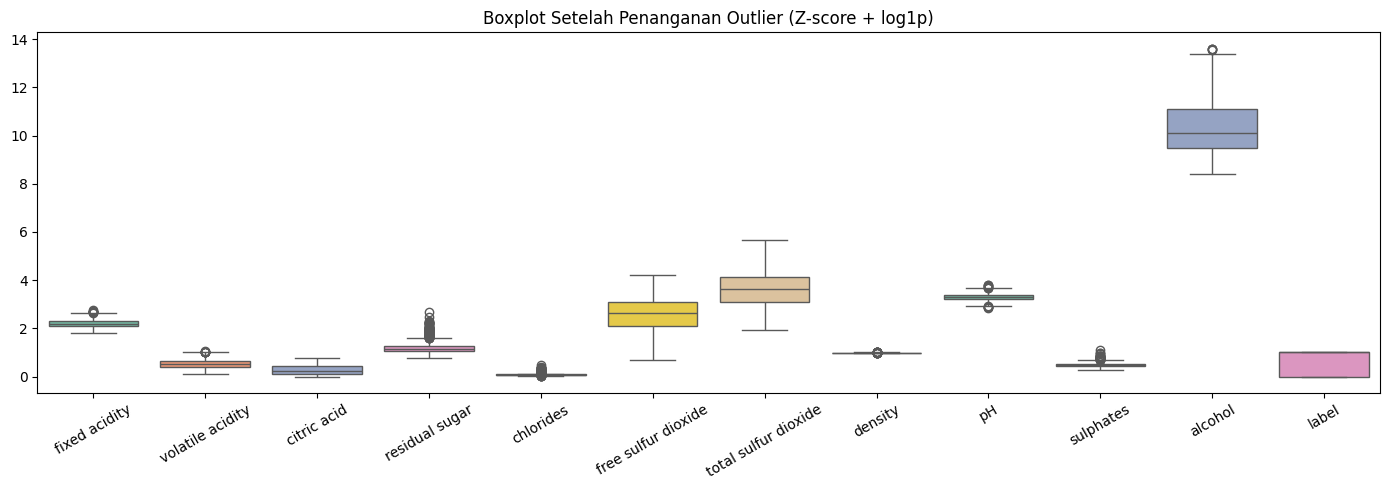

In [29]:
features = data_clean.drop(columns=['quality']).columns.tolist()
skew_vals = data_clean[features].skew().sort_values()

print(skew_vals.round(3))

threshold = 1.0  # |skew| < 1 dianggap mendekati normal
normal_features = skew_vals[skew_vals.abs() < threshold].index.tolist()
skewed_features = skew_vals[skew_vals.abs() >= threshold].index.tolist()

print("\nMendekati normal (pakai Z-score):", normal_features)
print("Skew (pakai log1p):", skewed_features)

data_fixed = data_clean.copy()

# --- A. Skew -> log1p (menekan ekor panjang + outlier) ---
for col in skewed_features:
    data_fixed[col] = np.log1p(data_fixed[col])

# --- B. Normal -> Z-score filtering (buang baris |z| > 3) ---
z_scores = (data_fixed[normal_features] - data_fixed[normal_features].mean()) / data_fixed[normal_features].std()
mask = (z_scores.abs() <= 3).all(axis=1)

print(f"Shape sebelum: {data_clean.shape}")
print(f"Baris dibuang sebagai outlier: {(~mask).sum()}")
data_fixed = data_fixed[mask].reset_index(drop=True)
print(f"Shape sesudah: {data_fixed.shape}")

plt.figure(figsize=(14, 5))
sns.boxplot(data=data_fixed[features], palette='Set2')
plt.title('Boxplot Setelah Penanganan Outlier (Z-score + log1p)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

di code tersebut saya mengatasi outliers yang ada pada visualisasi sebelumnya

Distribusi AWAL (6 kelas):
quality
3      5
4     30
5    425
6    399
7    119
8     14
Name: count, dtype: int64

Distribusi SESUDAH (2 kelas):
quality_label
good    532
bad     460
Name: count, dtype: int64
quality_label
good    53.63
bad     46.37
Name: proportion, dtype: float64


C:\Users\pranaja\AppData\Local\Temp\ipykernel_12700\2108099240.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_binary, x='quality', palette='viridis', ax=axes[0])
C:\Users\pranaja\AppData\Local\Temp\ipykernel_12700\2108099240.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_binary, x='quality_label', order=['bad','good'], palette='coolwarm', ax=axes[1])


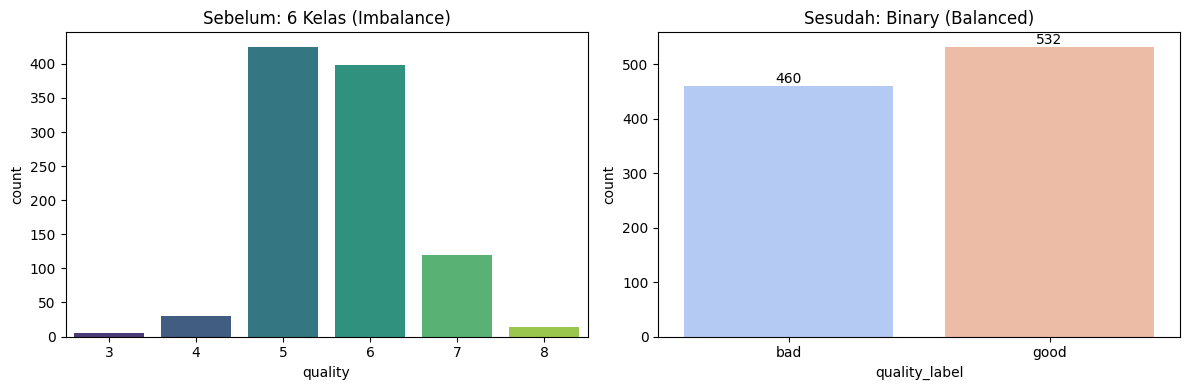

In [30]:
df_binary = data_fixed.copy()

# 3,4,5 -> bad (0), 6,7,8 -> good (1)
df_binary['quality_label'] = df_binary['quality'].apply(
    lambda x: 'bad' if x in [3, 4, 5] else 'good'
)
df_binary['quality_binary'] = (df_binary['quality'] >= 6).astype(int)

# Cek distribusi sebelum vs sesudah
print("Distribusi AWAL (6 kelas):")
print(df_binary['quality'].value_counts().sort_index())
print("\nDistribusi SESUDAH (2 kelas):")
print(df_binary['quality_label'].value_counts())
print((df_binary['quality_label'].value_counts(normalize=True)*100).round(2))
# Visualisasi perbandingan
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df_binary, x='quality', palette='viridis', ax=axes[0])
axes[0].set_title('Sebelum: 6 Kelas (Imbalance)')

sns.countplot(data=df_binary, x='quality_label', order=['bad','good'], palette='coolwarm', ax=axes[1])
axes[1].set_title('Sesudah: Binary (Balanced)')

# tampilkan angka di atas bar kanan
for p in axes[1].patches:
    axes[1].text(p.get_x() + p.get_width()/2, p.get_height() + 5,
                 int(p.get_height()), ha='center')

plt.tight_layout()
plt.show()

pembedaan quality tersebut untuk mencegah terjadinya imbalance data pada fitur quality dengan membuat 3, 4, dan 5 termasuk ke bad dan 6, 7, dan 8 termasuk ke good

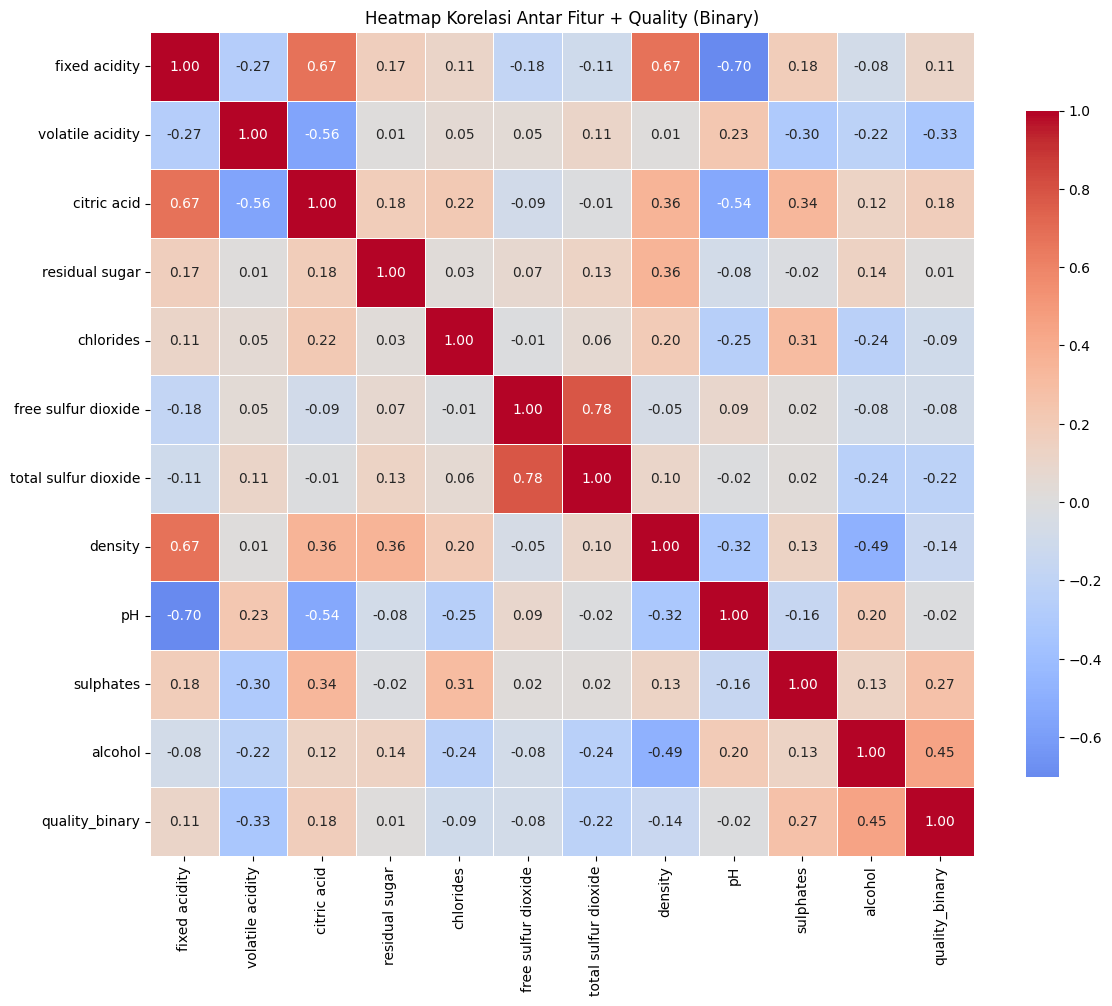

In [31]:
# Tampilkan Korelasi Matrix
corr_cols = X.columns.tolist() + ['quality_binary']  # X dari cell sebelumnya
# kalau belum ada X, ganti dengan:
# corr_cols = df_binary.drop(columns=['quality','quality_label']).columns.tolist()

corr = df_binary[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Heatmap Korelasi Antar Fitur + Quality (Binary)')
plt.tight_layout()
plt.show()

pada visualisasi tersebut korelasi dari setiap fitur pada dataset tersebut

               count    mean    std  min   25%   50%     75%   max
quality_label                                                     
bad            460.0   9.905  0.745  8.4   9.4   9.7  10.225  13.0
good           532.0  10.856  1.073  8.4  10.0  10.8  11.700  13.6


C:\Users\pranaja\AppData\Local\Temp\ipykernel_12700\127632740.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_binary, x='quality_label', y='alcohol',
C:\Users\pranaja\AppData\Local\Temp\ipykernel_12700\127632740.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_binary, x='quality_label', y='alcohol',


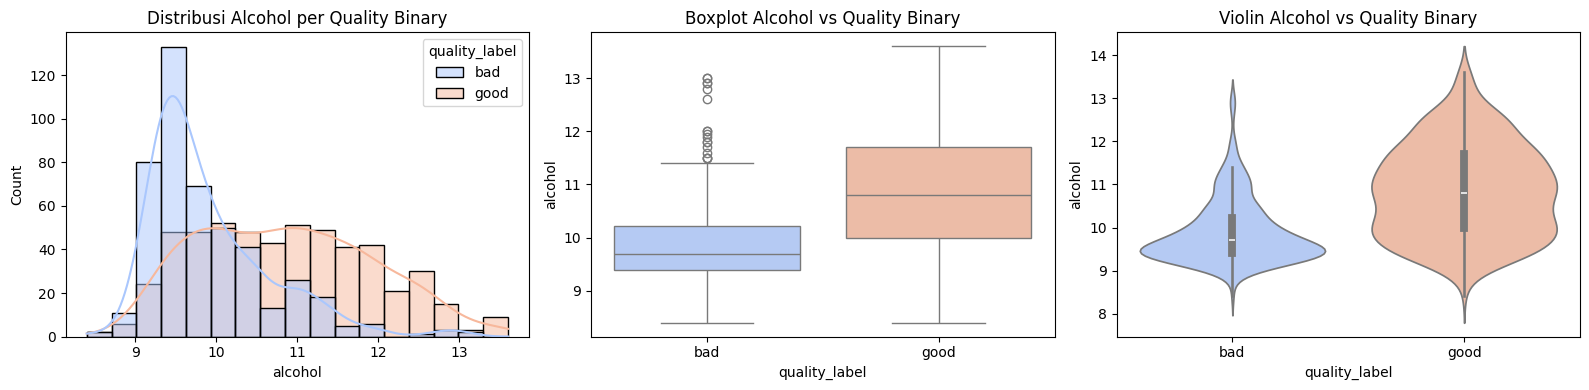

In [32]:
print(df_binary.groupby('quality_label')['alcohol'].describe().round(3))
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Histogram + KDE overlay
sns.histplot(data=df_binary, x='alcohol', hue='quality_label',
             hue_order=['bad','good'], kde=True,
             palette='coolwarm', alpha=0.5, ax=axes[0])
axes[0].set_title('Distribusi Alcohol per Quality Binary')

# 2. Boxplot
sns.boxplot(data=df_binary, x='quality_label', y='alcohol',
            order=['bad','good'], palette='coolwarm', ax=axes[1])
axes[1].set_title('Boxplot Alcohol vs Quality Binary')

# 3. Violin (bentuk distribusi lebih jelas)
sns.violinplot(data=df_binary, x='quality_label', y='alcohol',
               order=['bad','good'], palette='coolwarm', ax=axes[2])
axes[2].set_title('Violin Alcohol vs Quality Binary')

plt.tight_layout()
plt.show()

visulisasi ini menunjukkan kalau quality yang termasuk bad cenderung memiliki alkohol yang lebih rendah dan kualitas wine yang bagus cenderung mengandung alkohol lebih tinggi

## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan. 

# 2. Preprocessing




In [33]:
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler. (Bisa dilakukan eksperimen dengan dan tanpa scaling untuk melihat perbedaan performa model)
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit HANYA di train agar tidak data leakage, lalu transform keduanya
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Opsional: kembalikan jadi DataFrame agar nama kolom tetap
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Cek hasil: mean train ~= 0, std ~= 1
display(X_train_scaled.head())
print(X_train_scaled.describe().round(2))

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
388,-1.148726,-0.932297,-0.400554,0.537230,-0.264382,-0.067431,-0.194616,-0.562509,1.626872,-0.836838,2.013491
438,0.174015,-0.222569,1.235325,-0.404393,7.386931,0.029546,0.509393,0.645790,-1.841526,3.251158,-1.339322
809,-0.746153,0.869319,-1.371858,-0.482862,0.595564,-1.231155,-1.082279,-0.163245,0.252601,-0.333700,-0.705006
690,-0.746153,0.050403,-0.911767,-0.404393,-0.132083,-0.552316,-0.898624,-0.988040,0.776133,-0.396592,0.926092
1002,-0.171048,-1.259863,1.848780,-0.718267,-0.132083,0.029546,-0.500706,-0.415411,-0.074606,0.798361,0.291776


       fixed acidity  volatile acidity  citric acid  residual sugar  \
count         814.00            814.00       814.00          814.00   
mean           -0.00              0.00         0.00           -0.00   
std             1.00              1.00         1.00            1.00   
min            -1.95             -2.24        -1.37           -1.27   
25%            -0.69             -0.77        -0.91           -0.48   
50%            -0.23             -0.06        -0.09           -0.25   
75%             0.46              0.60         0.78            0.07   
max             4.37              5.73         3.74           10.19   

       chlorides  free sulfur dioxide  total sulfur dioxide  density      pH  \
count     814.00               814.00                814.00   814.00  814.00   
mean        0.00                -0.00                  0.00    -0.00    0.00   
std         1.00                 1.00                  1.00     1.00    1.00   
min        -1.17                -1.43   

pada cell tersebut scaling membuat untuk menyamakan jarak antar fitur karena rentang antar fitur berbeda beda

# 3. Eksperimen Model KNN


,train_acc,test_acc,test_precision,test_recall,test_f1
k,,,,,
1,1.0000,0.6765,0.6784,0.6765,0.6768
3,0.8464,0.6912,0.6907,0.6912,0.6908
5,0.8071,0.6961,0.6957,0.6961,0.6958
7,0.7887,0.7206,0.7208,0.7206,0.7207
9,0.7740,0.7010,0.7025,0.7010,0.7013


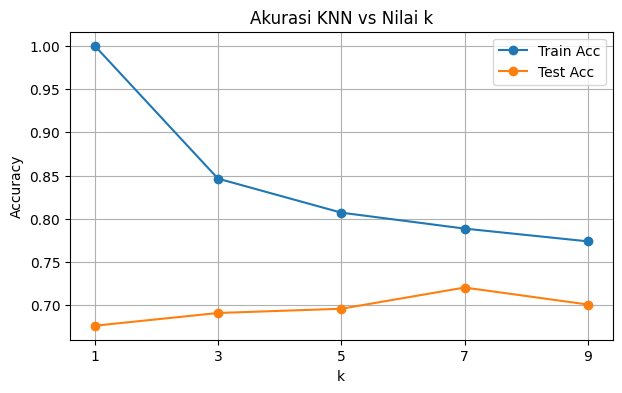

k terbaik: 7
              precision    recall  f1-score   support

           0       0.70      0.71      0.70        95
           1       0.74      0.73      0.74       109

    accuracy                           0.72       204
   macro avg       0.72      0.72      0.72       204
weighted avg       0.72      0.72      0.72       204



In [34]:
# Split data menjadi train dan test set. (misal 80% train, 20% test)
# Gunakan fungsi train_test_split dari sklearn.model_selection untuk membagi data menjadi train dan test set. Pastikan untuk memisahkan fitur (X) dan label (y) sebelum melakukan split.
# Gunakan stratify=y agar distribusi label pada train dan test set tetap sama dengan distribusi label pada dataset asli.
# Train model KNN menggunakan train set. Gunakan fungsi KNeighborsClassifier dari sklearn.neighbors untuk membuat model KNN. Lakukan eksperimen dengan berbagai nilai k (misal k=1, 3, 5, 7, 9) dan catat performa model pada train set dan test set.
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

k_list = [1, 3, 5, 7, 9]
results = []

for k in k_list:
    model = KNeighborsClassifier(n_neighbors=k)  # default metric euclidean
    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    results.append({
        'k': k,
        'train_acc': accuracy_score(y_train, y_train_pred),
        'test_acc': accuracy_score(y_test, y_test_pred),
        'test_precision': precision_score(y_test, y_test_pred, average='weighted', zero_division=0),
        'test_recall': recall_score(y_test, y_test_pred, average='weighted', zero_division=0),
        'test_f1': f1_score(y_test, y_test_pred, average='weighted', zero_division=0),
    })

import pandas as pd
df_results = pd.DataFrame(results).set_index('k')
display(df_results.round(4))

# Visualisasi
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(df_results.index, df_results['train_acc'], marker='o', label='Train Acc')
plt.plot(df_results.index, df_results['test_acc'], marker='o', label='Test Acc')
plt.xticks(k_list)
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Akurasi KNN vs Nilai k')
plt.legend()
plt.grid(True)
plt.show()

best_k = df_results['test_acc'].idxmax()
print(f"k terbaik: {best_k}")

best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred, zero_division=0))

# 4. Evaluasi Model


F1 per-kelas : [0.70157068 0.73732719]
F1 macro    : 0.7194
F1 weighted : 0.7207
F1 micro    : 0.7206

              precision    recall  f1-score   support

           0       0.70      0.71      0.70        95
           1       0.74      0.73      0.74       109

    accuracy                           0.72       204
   macro avg       0.72      0.72      0.72       204
weighted avg       0.72      0.72      0.72       204



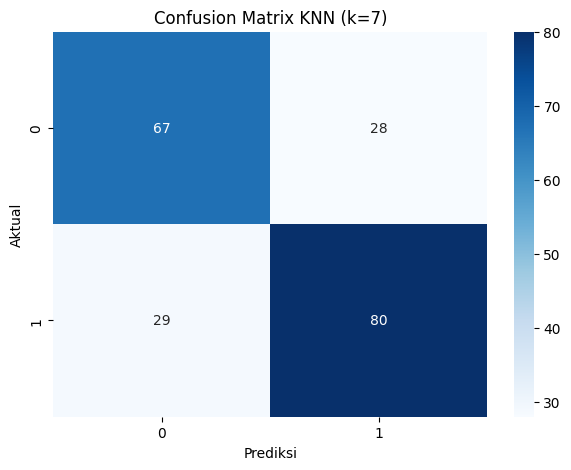

In [35]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. F1 per-kelas, macro, weighted, micro
print("F1 per-kelas :", f1_score(y_test, y_pred, average=None, zero_division=0))
print("F1 macro    :", round(f1_score(y_test, y_pred, average='macro', zero_division=0), 4))
print("F1 weighted :", round(f1_score(y_test, y_pred, average='weighted', zero_division=0), 4))
print("F1 micro    :", round(f1_score(y_test, y_pred, average='micro', zero_division=0), 4))
print()

# 2. Report lengkap
print(classification_report(y_test, y_pred, zero_division=0))

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=sorted(y_test.unique()))

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y_test.unique()),
            yticklabels=sorted(y_test.unique()))
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title(f'Confusion Matrix KNN (k={best_k})')
plt.show()

dari percobaan yang ada terlihat bahwa K yang menghasilkan f1 score terbaik yaitu pada saat K = 7 dengan menghasilkan F1 score 0.72

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen model KNN yang telah dilakukan. Bandingkan hasil antar eksperimen yang telah dilakukan. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.  

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.